<a href="https://colab.research.google.com/github/Mohammed287-lab/ANN/blob/main/%D8%AA%D9%86%D9%82%D9%8A%D8%A8%20%D8%A7%D9%84%D8%A8%D9%8A%D8%A7%D9%86%D8%A7%D8%AA%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install python-pptx
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.3 MB/s eta 0:00:00


In [ ]:
plt.ion()

In [3]:
print("Step 1-4: Loading and cleaning customer behavior dataset...")
df = pd.read_csv('Customer_Data.csv')
df.fillna({'CREDIT_LIMIT': df['CREDIT_LIMIT'].median(), 'MINIMUM_PAYMENTS': df['MINIMUM_PAYMENTS'].median()}, inplace=True)
scaled_features = StandardScaler().fit_transform(df.drop(columns=['CUST_ID']))

Step 1-4: Loading and cleaning customer behavior dataset...


In [5]:
def display_and_save_plot(filename, title, xlabel, ylabel, setup_fn):
    plt.figure(figsize=(8, 5) if "Elbow" in title else (10, 7))
    setup_fn()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    plt.pause(2.0)

In [6]:
print("Step 5: Evaluating optimal cluster count using the Elbow Method...")
k_range = range(1, 11)
wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_features).inertia_ for k in k_range]

Step 5: Evaluating optimal cluster count using the Elbow Method...


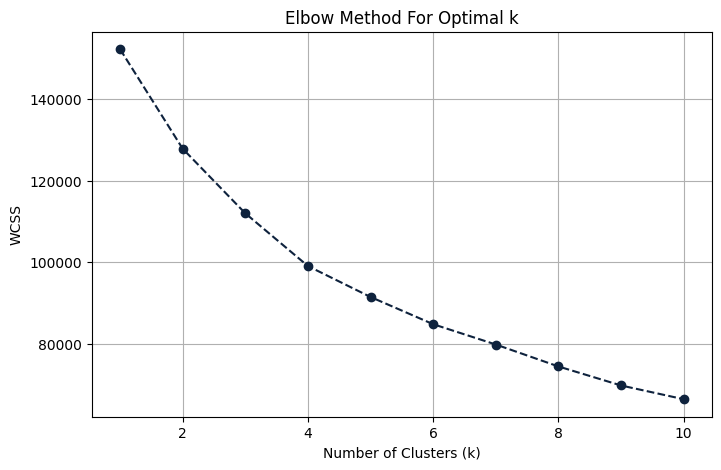

Executing finalized K-Means calculation (k=4)...
Model Evaluation: Silhouette Score: 0.198


In [7]:
display_and_save_plot('elbow_method.png', 'Elbow Method For Optimal k', 'Number of Clusters (k)', 'WCSS',
                      lambda: plt.plot(k_range, wcss, marker='o', linestyle='--', color='#0e223d'))

print("Executing finalized K-Means calculation (k=4)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)
print(f"Model Evaluation: Silhouette Score: {silhouette_score(scaled_features, kmeans.labels_):.3f}")

In [9]:
print("Step 6: Compressing metrics via PCA for 2D visual mapping...")
pca_features = PCA(n_components=2).fit_transform(scaled_features)
df['PCA1'], df['PCA2'] = pca_features[:, 0], pca_features[:, 1]
df.to_csv('Customer_Data_Clustered.csv', index=False)


def draw_scatter():
    scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis', alpha=0.6)
    plt.legend(*scatter.legend_elements(), title="Clusters")

Step 6: Compressing metrics via PCA for 2D visual mapping...


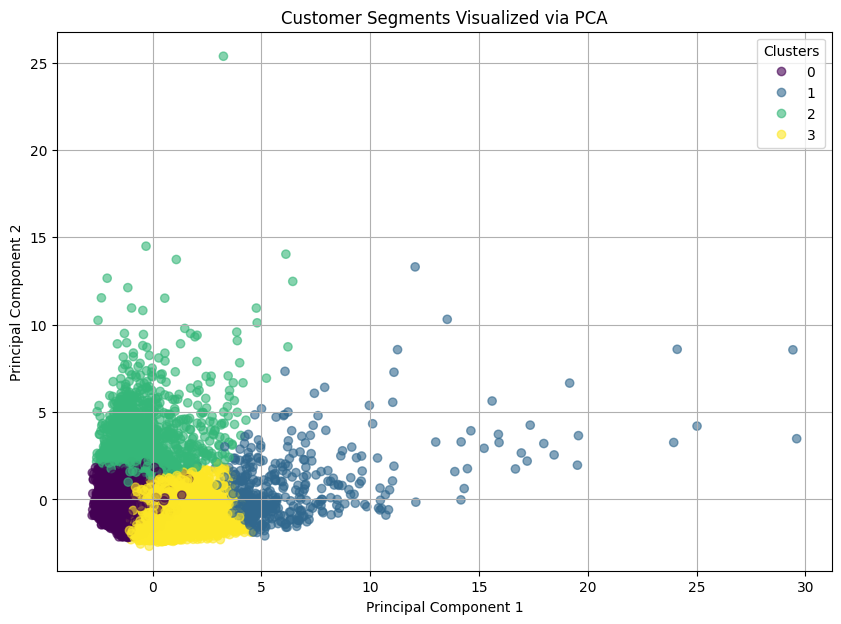

In [10]:
display_and_save_plot('customer_segments.png', 'Customer Segments Visualized via PCA', 'Principal Component 1', 'Principal Component 2', draw_scatter)

In [11]:
print("Step 7-8: Compiling presentation report templates...")
prs = Presentation()
prs.slide_width, prs.slide_height = Inches(13.33), Inches(7.5)
DARK_BLUE, LIGHT_BLUE, TEXT_DARK, WHITE = RGBColor(14,34,61), RGBColor(220,230,242), RGBColor(30,30,30), RGBColor(255,255,255)

slides_data = [
    {"title": "1. Problem Definition & Data Collection", "img": None, "bullets": [
        ("Step 1: Problem Definition", True),
        ("• Objective: Uncover distinct buyer personas among credit card holders to drive custom bank marketing campaigns.", False),
        ("• Approach: Apply unsupervised learning techniques to group users with highly similar financial habits.", False),
        ("", False),
        ("Step 2: Data Collection", True),
        ("• Source: Customer Credit Card Usage dataset containing 8,950 consumer profiles.", False),
        ("• Features: 18 variables spanning Balance, Purchases, Cash Advances, and Credit Limit over a 6-month period.", False)]},
    {"title": "2. Data Preprocessing & EDA", "img": None, "bullets": [
        ("Step 3: Data Preprocessing", True),
        ("• Missing Values: Imputed missing entries in CREDIT_LIMIT and MINIMUM_PAYMENTS with column medians.", False),
        ("• Column Filtering: Dropped CUST_ID as arbitrary categorical string keys disrupt algorithmic calculations.", False),
        ("• Feature Scaling: Transformed records via StandardScaler to equalize impact.", False),
        ("", False),
        ("Step 4: Exploratory Data Analysis (EDA)", True),
        ("• Identified strong variance and right-skewness across transaction columns.", False)]},
    {"title": "3. Model Selection: The Elbow Method", "img": "elbow_method.png", "bullets": [
        ("Step 5: Model Selection", True),
        ("• Selected K-Means Clustering for centroid-based partitions.", False),
        ("• Calculated Within-Cluster Sum of Squares (WCSS) across iterations to evaluate split quality.", False),
        ("• Chosen Optimal Clusters: k = 4, where the marginal reduction in distortion reaches an elbow point.", False)]},
    {"title": "4. Model Evaluation & Visualization", "img": "customer_segments.png", "bullets": [
        ("Step 6: Model Evaluation", True),
        ("• Calculated Silhouette Score to ensure distinct cluster margins.", False),
        ("• Applied Principal Component Analysis (PCA) to compress 17 features into 2 dimensions.", False)]},
    {"title": "5. Results Interpretation & Personas", "img": None, "bullets": [
        ("Step 7: Results Interpretation", True),
        ("• Segment 0 (Cash Advance Users): High balance, minimal purchase behavior, heavy cash advances.", False),
        ("• Segment 1 (Frugal/Budget Group): Low balance levels, low transaction metrics, lower credit limits.", False),
        ("• Segment 2 (VIP Power Spenders): Highest purchase metrics, substantial balances, elevated credit capacity.", False),
        ("• Segment 3 (Regular Active Buyers): Consistent purchase activity, low cash advance dependencies.", False)]},
    {"title": "6. Strategic Recommendations & Reporting", "img": None, "bullets": [
        ("Step 8: Reporting & Strategy Execution", True),
        ("• Action for VIPs (Segment 2): Roll out exclusive premium cashback schemes and concierge benefits.", False),
        ("• Action for Cash Borrowers (Segment 0): Introduce personalized low-interest installment loan options.", False),
        ("• Action for Regular Buyers (Segment 3): Offer buy-now-pay-later (BNPL) structures to increase basket sizes.", False),
        ("• Action for Frugal Group (Segment 1): Send localized retail zero-fee transaction activation vouchers.", False)]}
]

Step 7-8: Compiling presentation report templates...


In [12]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
slide.background.fill.solid(); slide.background.fill.fore_color.rgb = DARK_BLUE
tf = slide.shapes.add_textbox(Inches(1), Inches(2.5), Inches(11.33), Inches(2)).text_frame
tf.word_wrap = True
for txt, size, color in [("Customer Segmentation using K-Means Clustering", 44, WHITE), ("Data Mining Course Project Report", 24, LIGHT_BLUE)]:
    p = tf.add_paragraph() if tf.text else tf.paragraphs[0]
    p.text = txt; p.font.size = Pt(size); p.font.color.rgb = color; p.font.bold = (size == 44)

# Generate Content Slides via Loop
for s in slides_data:
    slide = prs.slides.add_slide(prs.slide_layouts[6])
    slide.background.fill.solid(); slide.background.fill.fore_color.rgb = WHITE

    tx = slide.shapes.add_textbox(Inches(0.75), Inches(0.5), Inches(11.83), Inches(1))
    p = tx.text_frame.paragraphs[0]
    p.text, p.font.size, p.font.bold, p.font.color.rgb = s["title"], Pt(32), True, DARK_BLUE

    w = Inches(5.5) if s["img"] else Inches(11.83)
    tf = slide.shapes.add_textbox(Inches(0.75), Inches(1.8), w, Inches(5)).text_frame
    tf.word_wrap = True

    for text, is_bold in s["bullets"]:
        p = tf.add_paragraph() if tf.text else tf.paragraphs[0]
        p.text = text
        p.level = 0 if is_bold else 1
        p.font.size = Pt(22) if is_bold else Pt(18)
        p.font.color.rgb, p.font.bold, p.font.name = TEXT_DARK, is_bold, 'Arial'

    if s["img"] and os.path.exists(s["img"]):
        slide.shapes.add_picture(s["img"], Inches(6.5), Inches(1.5 if "segments" in s["img"] else 1.8), width=Inches(6.3 if "segments" in s["img"] else 6.2))

prs.save('Customer_Segmentation_Presentation.pptx')
print("Presentation generated successfully.")

Presentation generated successfully.


In [13]:
plt.ioff()
print("Process completed. Close the plot windows to terminate script completely.")
plt.show()

Process completed. Close the plot windows to terminate script completely.
